# Kwant energy–magnetic-field conductance map

This notebook follows the same architecture, conventions, potential preparation,
lead-mouth reshaping/cropping, chemical-potential selector, magnetic-field
construction, and JOBLIB parallelization as
`kwant_G_cropped_JOBLIB_finite_T(2).ipynb`.

The difference is that, instead of using a thermal window around the Hartree
chemical potential, it computes the zero-temperature two-terminal conductance

\[
G_0(E,B)
\]

on a **fixed energy-offset grid**

\[
\delta E = E-\mu(B),
\]

and plots the resulting color map.  Thus the horizontal line
\(\delta E=0\) is exactly the Hartree chemical potential trajectory.

This is intended as a diagnostic of whether the sharp steps in \(G(B)\) arise
because \(\mu(B)\) crosses an intrinsically narrow transport transition, or
because of the particular alignment of the Hartree chemical potential with the
cropped Kwant potential.

In [39]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
import multiprocessing

from module_kwant import *

In [40]:
SWEEP_DIR = Path("data_sweep")
POTENTIAL_KEY = "U"

seq = load_effective_potential_sequence(
    SWEEP_DIR,
    potential_key=POTENTIAL_KEY,
    ground_each_frame=False,
)

print(seq.U_stack_meV.shape, "(nB, ny, nx)")
print("B range:", seq.B_values_T[0], "->", seq.B_values_T[-1], "T")
print("x range:", seq.x_nm.min(), "->", seq.x_nm.max(), "nm")
print("y range:", seq.y_nm.min(), "->", seq.y_nm.max(), "nm")
print("grid spacing a =", seq.a_nm, "nm")

(201, 151, 301) (nB, ny, nx)
B range: 0.6856013737026843 -> 2.0 T
x range: -1000.0 -> 1000.0 nm
y range: -500.0 -> 500.0 nm
grid spacing a = 6.666666666666667 nm


In [41]:
# Choose one representative frame for visualization/building.
FRAME_INDEX = 0  #min(101, len(seq.B_values_T) - 1)

# Lead-mouth parameters.
source_drain_depth_nm = 400.0     # reshaping depth for left/right current leads

lead_potential_meV = 0.0
smooth_nm = 1e1

lead_specs_2 = (
    LeadSpec(
        "source", "left",
        depth_nm=source_drain_depth_nm,
        lead_potential_meV=lead_potential_meV,
        smooth_nm=smooth_nm,
        smooth_profile="constant_inner",
    ),
    LeadSpec(
        "drain", "right",
        depth_nm=source_drain_depth_nm,
        lead_potential_meV=lead_potential_meV,
        smooth_nm=smooth_nm,
        smooth_profile="constant_inner",
    ),
)

#EFFECTIVE MASS SHOULD BE 0.067 BUT SINCE IN PREVIOUS SIMULATIONS I USED EB=1.76 * B I MUST USE THIS NEW ONE
cfg2 = DeviceConfig(
    m_eff=0.0658,
    g_factor=-0.0,
    norbs=1,
    disorder=DisorderConfig(amplitude_meV=1e-10, correlation_nm=50.0, seed=None),
    lead_specs=lead_specs_2,
    reshape_under_leads=True,
    lead_B_mode="zero",
)


# -------------------------------------------------------------------------
# Geometry optimization:
# 1) run the ORIGINAL v4 prepare_frame on the full Hartree grid, so the
#    source/drain mouths are reshaped exactly as before;
# 2) only afterwards discard the reshaped left/right sections;
# 3) make run_one_frame use this same cropped preparation also inside
#    JOBLIB worker processes.
# -------------------------------------------------------------------------

_prepare_frame_full = prepare_frame
_run_one_frame_full = run_one_frame


def crop_prepared_frame_x(prep, crop_depth_nm):
    """
    Return a copy of a v4 PreparedFrame restricted to the inner x interval

        xmin + crop_depth_nm < x < xmax - crop_depth_nm.

    The crop is applied to x_nm and to every prepared ndarray whose final
    spatial dimensions are (ny, nx), plus any 1D x-dependent array.

    This function deliberately acts AFTER the original v4 prepare_frame,
    hence U_for_transport_meV has already undergone the original lead-mouth
    reshaping before the outer regions are thrown away.
    """
    import copy
    import dataclasses

    x = np.asarray(prep.x_nm)
    y = np.asarray(prep.y_nm)
    nx = len(x)
    ny = len(y)

    xmin = float(x.min())
    xmax = float(x.max())

    x_left = xmin + float(crop_depth_nm)
    x_right = xmax - float(crop_depth_nm)

    keep_x = (x > x_left) & (x < x_right)

    if np.count_nonzero(keep_x) < 2:
        raise ValueError(
            "source_drain_depth_nm removes the whole transport region: "
            f"full x range = [{xmin}, {xmax}] nm, "
            f"requested retained interval = ({x_left}, {x_right}) nm."
        )

    def crop_value(name, value):
        # Coordinate arrays must be treated explicitly.
        if name == "x_nm":
            return np.asarray(value)[keep_x]

        if name == "y_nm":
            return np.asarray(value)   # NEVER crop y

        if not isinstance(value, np.ndarray):
            return value

        # Spatial maps: crop ONLY their x axis.
        if value.ndim >= 2 and value.shape[-2:] == (ny, nx):
            sl = [slice(None)] * value.ndim
            sl[-1] = keep_x
            return value[tuple(sl)]

        # 1D arrays known to live on x.
        # Only use this generic rule after excluding y_nm explicitly.
        if value.ndim == 1 and value.shape[0] == nx:
            return value[keep_x]

        return value

    if dataclasses.is_dataclass(prep):
        updates = {}
        for f in dataclasses.fields(prep):
            old = getattr(prep, f.name)
            new = crop_value(f.name, old)
            if new is not old:
                updates[f.name] = new
        cropped = dataclasses.replace(prep, **updates)
    else:
        # Fallback for a non-dataclass PreparedFrame implementation.
        cropped = copy.copy(prep)
        for name, old in vars(prep).items():
            new = crop_value(name, old)
            if new is not old:
                setattr(cropped, name, new)

    return cropped


def prepare_frame(seq, index, cfg):
    """Original v4 frame preparation followed by the inner-x crop."""
    prep_full = _prepare_frame_full(seq, index, cfg)
    return crop_prepared_frame_x(prep_full, source_drain_depth_nm)


def run_one_frame(*args, **kwargs):
    """
    Call the original v4 run_one_frame, but temporarily replace the module's
    prepare_frame by the cropped wrapper above.

    Doing the patch inside this function is intentional: JOBLIB/loky workers
    import the v4 module in separate processes, so each worker must activate
    the cropped preparation locally before running a frame.
    """
    module_globals = _run_one_frame_full.__globals__
    previous_prepare_frame = module_globals.get("prepare_frame")
    module_globals["prepare_frame"] = prepare_frame
    try:
        return _run_one_frame_full(*args, **kwargs)
    finally:
        module_globals["prepare_frame"] = previous_prepare_frame


# Prepare one frame through the NEW cropped path.
prep2 = prepare_frame(seq, FRAME_INDEX, cfg2)

# Also prepare the corresponding full frame only for diagnostics.
prep2_full = _prepare_frame_full(seq, FRAME_INDEX, cfg2)

print("lead order:")
for i, spec in enumerate(cfg2.lead_specs):
    print(i, spec)
print("B =", prep2.B_T, "T")
print("t =", prep2.t_meV, "meV")
print("alpha =", prep2.alpha)
print("lB =", prep2.lB_nm, "nm")
print("full grid shape   =", prep2_full.U_for_transport_meV.shape)
print("cropped grid shape=", prep2.U_for_transport_meV.shape)
print(
    "x retained:",
    float(prep2.x_nm.min()), "->", float(prep2.x_nm.max()), "nm",
)
print(
    "site-count reduction factor ≈",
    prep2_full.U_for_transport_meV.size / prep2.U_for_transport_meV.size,
)


lead order:
0 LeadSpec(name='source', side='left', center_nm=None, width_nm=None, depth_nm=400.0, lead_potential_meV=0.0, smooth_nm=10.0, smooth_profile='constant_inner')
1 LeadSpec(name='drain', side='right', center_nm=None, width_nm=None, depth_nm=400.0, lead_potential_meV=0.0, smooth_nm=10.0, smooth_profile='constant_inner')
B = 0.6856013737026843 T
t = 13.028054361702127 meV
alpha = 0.007367896650409155
lB = 30.987778862221074 nm
full grid shape   = (151, 301)
cropped grid shape= (151, 179)
x retained: -593.3333333333333 -> 593.3333333333335 nm
site-count reduction factor ≈ 1.681564245810056


## Energy-map settings

Unlike the finite-temperature notebook, the energy interval is not specified in
units of \(k_B T\).  It is a fixed interval around the Hartree chemical
potential, so that maps at different magnetic fields can be compared directly.

`ENERGY_HALF_WIDTH_MEV = 0.5` means that each frame is evaluated over

\[
\mu(B)-0.5\ {\rm meV} \le E \le \mu(B)+0.5\ {\rm meV}.
\]

Increase `N_ENERGY_POINTS` for a finer determination of the transition width.
The computational cost is approximately

`number of B frames × N_ENERGY_POINTS`

Kwant scattering-matrix evaluations.

In [42]:
# -------------------------------------------------------------------------
# Energy-map settings
# -------------------------------------------------------------------------

ENERGY_HALF_WIDTH_MEV = 0.5
N_ENERGY_POINTS = 31

if N_ENERGY_POINTS < 3 or N_ENERGY_POINTS % 2 == 0:
    raise ValueError("N_ENERGY_POINTS must be an odd integer >= 3.")

energy_offsets_meV = np.linspace(
    -ENERGY_HALF_WIDTH_MEV,
    +ENERGY_HALF_WIDTH_MEV,
    N_ENERGY_POINTS,
)

print("Energy-map settings")
print(
    "E - mu window =",
    energy_offsets_meV[0],
    "->",
    energy_offsets_meV[-1],
    "meV",
)
print("energy points per B =", N_ENERGY_POINTS)
print("delta E at central point =", energy_offsets_meV[N_ENERGY_POINTS // 2], "meV")


Energy-map settings
E - mu window = -0.5 -> 0.5 meV
energy points per B = 31
delta E at central point = 0.0 meV


## Hartree chemical-potential selector

This is kept identical to the finite-temperature notebook.  The optional
finite-discretization correction is also retained in the same form and remains
disabled by the final factor `*0`, exactly as in the original notebook.

In [43]:
selector = hartree_energy_selector(
    key_candidates=[
        "params.mu",
        "mu",
        "chemical_potential",
        "chemical_potential_meV",
        "fermi_energy",
        "fermi_energy_meV",
    ],
    unit="meV",
)


## Single-frame diagnostic

Before launching the complete sweep, this cell computes \(G_0(E)\) for one
Hartree frame.  The dashed vertical line is \(E=\mu\), i.e.
\(\delta E=0\).

B = 0.6856013737026843 T
mu = 12.952775136534582 meV
hbar omega_c = 1.20623788775559 meV
absolute energy window = 12.452775136534582 -> 13.452775136534582 meV
number of energy points = 31
G(E=mu) [e^2/h] = 10.999755114461106


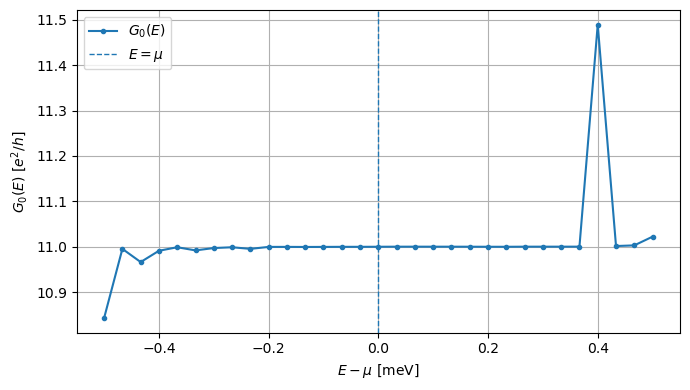

In [44]:
import kwant

FRAME_INDEX_MAP = FRAME_INDEX

frame = seq.frame(FRAME_INDEX_MAP)
mu_frame = float(selector(frame))
prep2 = prepare_frame(seq, FRAME_INDEX_MAP, cfg2)

# Same finite-discretization correction logic as in the original notebook.
ll_effective = np.around(
    mu_frame / (1.76 * prep2.B_T) - 0.5,
    decimals=0,
)
JJ = 38.0998212 / 0.067 / prep2.a_nm**2
EB = 1.76 * prep2.B_T

dE = -EB**2 / (32 * JJ) * (
    2 * ll_effective**2 + 2 * ll_effective + 1
) * 0

dE0 = -EB**2 / (32 * JJ) * (
    2 * (ll_effective - 1)**2 + 2 * (ll_effective - 1) + 1
) * 0

mu_frame += (dE + dE0) / 2

# Build/finalize only once for this B.
builder2 = build_kwant_builder(prep2, cfg2)
fsyst2, phase_params2 = finalize_with_magnetic_field(
    builder2,
    prep2.B_T,
    len(cfg2.lead_specs),
    cfg2.lead_B_mode,
)

energy_grid_frame = mu_frame + energy_offsets_meV

G_energy_frame = np.empty(N_ENERGY_POINTS, dtype=float)

for j, E in enumerate(energy_grid_frame):
    smat_E = kwant.smatrix(
        fsyst2,
        energy=float(E),
        params=phase_params2,
    )

    T_E = transmission_matrix(smat_E)

    G_energy_frame[j] = two_terminal_conductance_e2h(
        T_E,
        source=0,
        drain=1,
    )

i_mu = N_ENERGY_POINTS // 2
G_mu_frame = float(G_energy_frame[i_mu])

print("B =", prep2.B_T, "T")
print("mu =", mu_frame, "meV")
print("hbar omega_c =", prep2.omega_c_meV, "meV")
print(
    "absolute energy window =",
    energy_grid_frame[0],
    "->",
    energy_grid_frame[-1],
    "meV",
)
print("number of energy points =", len(energy_grid_frame))
print("G(E=mu) [e^2/h] =", G_mu_frame)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    energy_offsets_meV,
    G_energy_frame,
    "o-",
    ms=3,
    label=r"$G_0(E)$",
)
ax.axvline(0.0, ls="--", lw=1, label=r"$E=\mu$")
ax.set_xlabel(r"$E-\mu$ [meV]")
ax.set_ylabel(r"$G_0(E)$ [$e^2/h$]")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()


## Parallel \(B\)-sweep

Each JOBLIB worker:

1. loads the same Hartree frame as in the original transport notebook;
2. performs the same lead-mouth preparation and post-preparation crop;
3. uses the same Hartree chemical potential;
4. builds/finalizes the Kwant system once for that \(B\);
5. evaluates the scattering matrix over the common \(E-\mu(B)\) grid.

Because every frame uses the same `energy_offsets_meV`, the resulting
`G_energy_e2h` array can be plotted directly as a rectangular color map.

In [45]:
B_STRIDE = 1

# Same convention as the attached finite-T notebook:
# use the first 35 frames by default.
indices = list(range(0, len(seq.B_values_T), B_STRIDE))
#indices = list(range(0, min(35, len(seq.B_values_T)), B_STRIDE))

# For the complete sweep instead, use:
# indices = list(range(0, len(seq.B_values_T), B_STRIDE))

N_JOBS = max(1, multiprocessing.cpu_count() - 1)


def run_one_index_energy_map(i):
    import kwant

    frame_i = seq.frame(i)
    mu_i = float(selector(frame_i))

    # Same cropped potential preparation as in the original notebook.
    prep_i = prepare_frame(seq, i, cfg2)

    # Same finite-discretization correction logic as in the original notebook.
    EB = 1.76 * prep_i.B_T
    ll_effective = np.around(mu_i / EB - 0.5, decimals=0)
    JJ = 38.0998212 / 0.067 / prep_i.a_nm**2

    dE = -EB**2 / (32 * JJ) * (
        2 * ll_effective**2 + 2 * ll_effective + 1
    ) * 0

    dE0 = -EB**2 / (32 * JJ) * (
        2 * (ll_effective - 1)**2
        + 2 * (ll_effective - 1)
        + 1
    ) * 0

    mu_i += dE0

    # Build/finalize exactly once for this B.
    builder_i = build_kwant_builder(prep_i, cfg2)
    fsyst_i, phase_params_i = finalize_with_magnetic_field(
        builder_i,
        prep_i.B_T,
        len(cfg2.lead_specs),
        cfg2.lead_B_mode,
    )

    energies_i = mu_i + energy_offsets_meV

    G_E_i = np.empty(N_ENERGY_POINTS, dtype=float)

    for j, E in enumerate(energies_i):
        smat_E = kwant.smatrix(
            fsyst_i,
            energy=float(E),
            params=phase_params_i,
        )

        T_E = transmission_matrix(smat_E)

        G_E_i[j] = two_terminal_conductance_e2h(
            T_E,
            source=0,
            drain=1,
        )

    i_mu = N_ENERGY_POINTS // 2

    return {
        "index": i,
        "B_T": float(prep_i.B_T),
        "mu_meV": float(mu_i),
        "energy_grid_meV": np.asarray(energies_i),
        "energy_offsets_meV": np.asarray(energy_offsets_meV),
        "G_energy_e2h": np.asarray(G_E_i),
        "G_mu_e2h": float(G_E_i[i_mu]),
    }


results_map = Parallel(
    n_jobs=N_JOBS,
    backend="loky",
    verbose=10,
)(
    delayed(run_one_index_energy_map)(i)
    for i in indices
)

results_map = sorted(results_map, key=lambda r: r["index"])

B = np.array([r["B_T"] for r in results_map])
mu = np.array([r["mu_meV"] for r in results_map])
G_mu = np.array([r["G_mu_e2h"] for r in results_map])

energy_grids_meV = np.stack(
    [r["energy_grid_meV"] for r in results_map],
    axis=0,
)

G_energy_e2h = np.stack(
    [r["G_energy_e2h"] for r in results_map],
    axis=0,
)

print("done", len(results_map), "frames")
print(
    "Kwant smatrix evaluations =",
    len(results_map) * N_ENERGY_POINTS,
)
print("G_energy_e2h shape =", G_energy_e2h.shape)


[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   4 tasks      | elapsed:   55.1s
[Parallel(n_jobs=7)]: Done  11 tasks      | elapsed:  1.8min
[Parallel(n_jobs=7)]: Done  18 tasks      | elapsed:  2.8min
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:  3.7min
[Parallel(n_jobs=7)]: Done  36 tasks      | elapsed:  5.5min
[Parallel(n_jobs=7)]: Done  47 tasks      | elapsed:  6.5min
[Parallel(n_jobs=7)]: Done  58 tasks      | elapsed:  8.4min
[Parallel(n_jobs=7)]: Done  71 tasks      | elapsed: 10.3min
[Parallel(n_jobs=7)]: Done  84 tasks      | elapsed: 11.4min
[Parallel(n_jobs=7)]: Done  99 tasks      | elapsed: 14.2min
[Parallel(n_jobs=7)]: Done 114 tasks      | elapsed: 16.2min
[Parallel(n_jobs=7)]: Done 131 tasks      | elapsed: 18.2min
[Parallel(n_jobs=7)]: Done 148 tasks      | elapsed: 21.1min
[Parallel(n_jobs=7)]: Done 167 tasks      | elapsed: 23.1min
[Parallel(n_jobs=7)]: Done 186 tasks      | elapsed: 26.0min
[Parallel(

done 201 frames
Kwant smatrix evaluations = 6231
G_energy_e2h shape = (201, 31)


## \(G_0(E-\mu,B)\) color map

The color map is plotted in the physically useful coordinates
\((B,E-\mu)\).  Therefore the Hartree chemical potential is the horizontal
line at \(E-\mu=0\).

Integer-conductance regions appear as bands in the map, while the boundaries
between them reveal the intrinsic energy width and \(B\)-dependence of the
transport transitions.

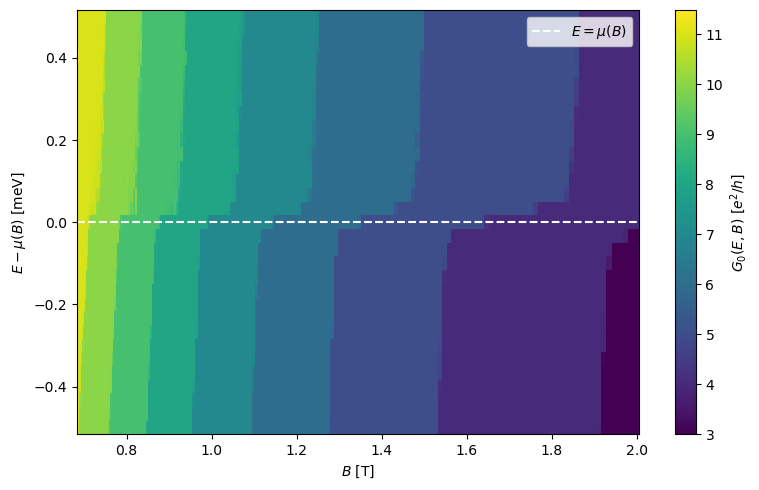

In [46]:
fig, ax = plt.subplots(figsize=(8, 5))

pc = ax.pcolormesh(
    B,
    energy_offsets_meV,
    G_energy_e2h.T,
    shading="auto",
)

ax.axhline(
    0.0,
    color="white",
    ls="--",
    lw=1.5,
    label=r"$E=\mu(B)$",
)

cbar = fig.colorbar(pc, ax=ax)
cbar.set_label(r"$G_0(E,B)$ [$e^2/h$]")

ax.set_xlabel(r"$B$ [T]")
ax.set_ylabel(r"$E-\mu(B)$ [meV]")
ax.legend(loc="best")

plt.tight_layout()
plt.show()


### Optional contour overlay

Integer-valued contours are useful for seeing whether a plateau boundary is
almost vertical in \(B\), has a substantial energy width, or bends relative to
the \(E=\mu(B)\) trajectory.

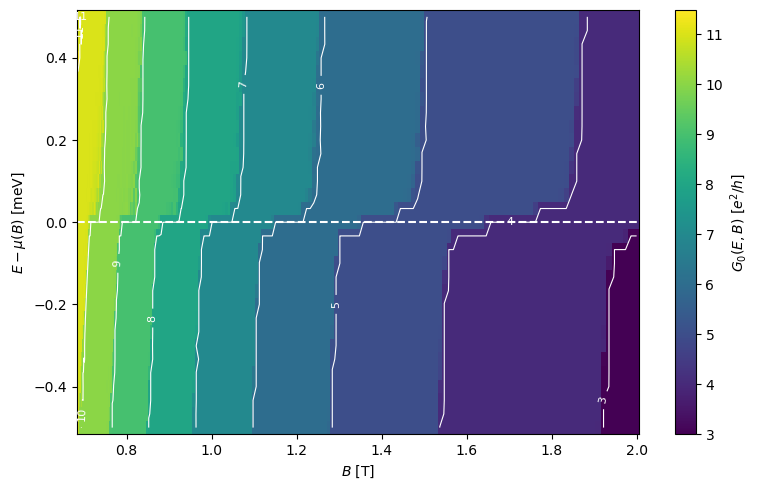

In [47]:
fig, ax = plt.subplots(figsize=(8, 5))

pc = ax.pcolormesh(
    B,
    energy_offsets_meV,
    G_energy_e2h.T,
    shading="auto",
)

gmin = float(np.nanmin(G_energy_e2h))
gmax = float(np.nanmax(G_energy_e2h))

levels = np.arange(
    np.ceil(gmin),
    np.floor(gmax) + 1,
    1.0,
)

if len(levels) > 0:
    cs = ax.contour(
        B,
        energy_offsets_meV,
        G_energy_e2h.T,
        levels=levels,
        colors="white",
        linewidths=0.8,
    )
    ax.clabel(cs, inline=True, fontsize=8, fmt="%g")

ax.axhline(
    0.0,
    color="white",
    ls="--",
    lw=1.5,
)

cbar = fig.colorbar(pc, ax=ax)
cbar.set_label(r"$G_0(E,B)$ [$e^2/h$]")

ax.set_xlabel(r"$B$ [T]")
ax.set_ylabel(r"$E-\mu(B)$ [meV]")

plt.tight_layout()

plt.savefig("Gmap.pdf")

plt.show()


## Check the cut at \(E=\mu(B)\)

This reproduces the zero-temperature conductance cut through the center of the
color map and is useful for checking consistency with the original notebook.

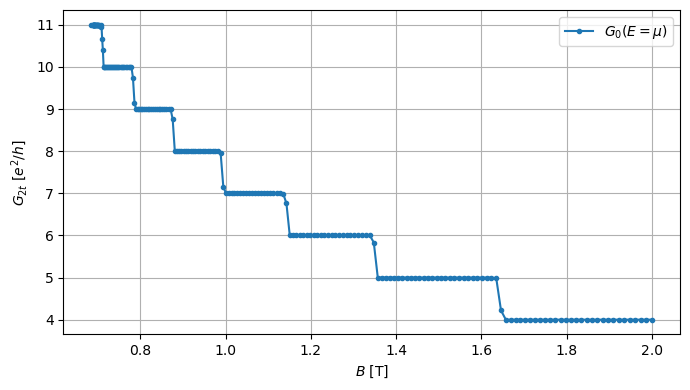

In [48]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    B,
    G_mu,
    marker="o",
    ms=3,
    label=r"$G_0(E=\mu)$",
)

ax.set_xlabel(r"$B$ [T]")
ax.set_ylabel(r"$G_{2t}$ [$e^2/h$]")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()


## Absolute-energy representation

The diagnostic map above intentionally subtracts the Hartree chemical
potential.  This second representation uses the absolute scattering energy.
Since \(\mu(B)\) generally varies with \(B\), the energy grids are not
rectangular in absolute \(E\), so the map is drawn from the actual
two-dimensional \((B,E)\) coordinates.  The Hartree \(\mu(B)\) is overlaid.

/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_56352/294678883.py:8: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pc = ax.pcolormesh(


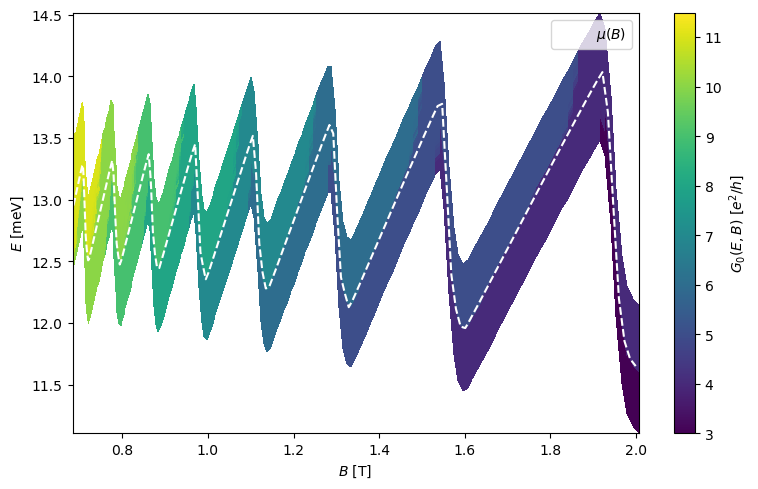

In [49]:
B_grid = np.broadcast_to(
    B[:, None],
    energy_grids_meV.shape,
)

fig, ax = plt.subplots(figsize=(8, 5))

pc = ax.pcolormesh(
    B_grid,
    energy_grids_meV,
    G_energy_e2h,
    shading="auto",
)

ax.plot(
    B,
    mu,
    color="white",
    ls="--",
    lw=1.5,
    label=r"$\mu(B)$",
)

cbar = fig.colorbar(pc, ax=ax)
cbar.set_label(r"$G_0(E,B)$ [$e^2/h$]")

ax.set_xlabel(r"$B$ [T]")
ax.set_ylabel(r"$E$ [meV]")
ax.legend(loc="best")

plt.tight_layout()
plt.show()


## Save results

The file contains both the common \(E-\mu\) grid and the absolute energy grid,
so it can later be replotted without rerunning Kwant.

In [50]:
outfile = "two_terminal_transport_energy_map.npz"

np.savez(
    outfile,
    B=B,
    mu=mu,
    indices=np.array([r["index"] for r in results_map]),

    energy_half_width_meV=np.array(ENERGY_HALF_WIDTH_MEV),
    n_energy_points=np.array(N_ENERGY_POINTS),
    energy_offsets_meV=energy_offsets_meV,
    energy_grids_meV=energy_grids_meV,

    G_energy_e2h=G_energy_e2h,
    G_mu=G_mu,

    source_drain_depth_nm=np.array(source_drain_depth_nm),
    lead_B_mode=np.array(cfg2.lead_B_mode),
)

print("saved", outfile)


saved two_terminal_transport_energy_map.npz
